In [57]:
### import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

### Data Preprocessing

In [58]:
### Load the dataset
df=pd.read_excel('EastWestAirlines.xlsx', sheet_name=1)

In [59]:
### Data size
df.shape

(3999, 12)

In [60]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [61]:
### First five rows of data
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [62]:
### Check Duplicates
df.duplicated().sum()

np.int64(0)

    No Duplicates

In [63]:
### Check Missing values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

    No Missing values

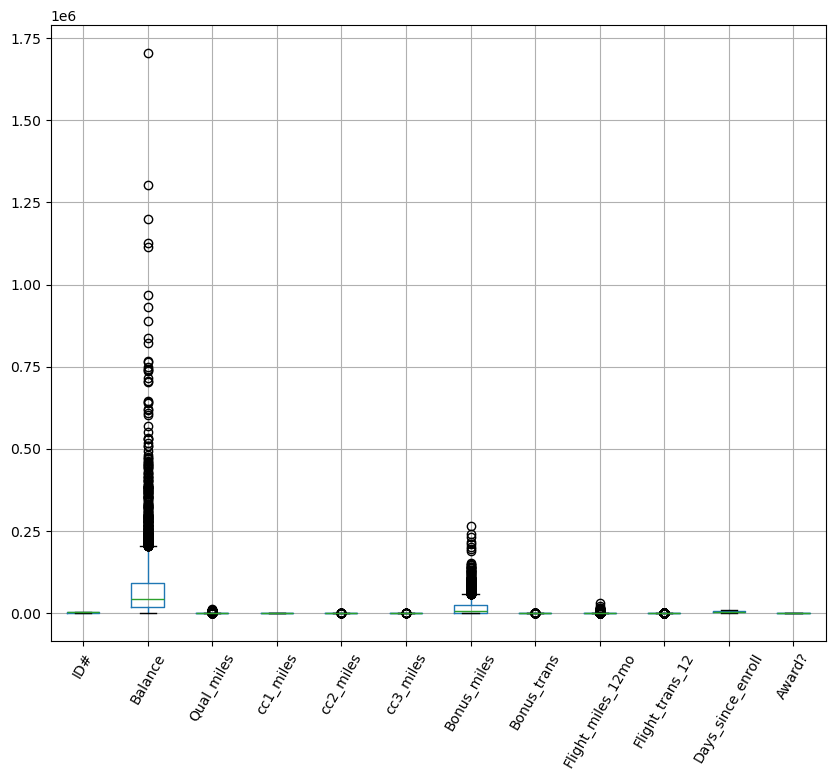

In [64]:
### Check Outliers
plt.figure(figsize=(10,8))
df.boxplot()
plt.xticks(rotation=60)
plt.show()

In [65]:
### Outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
cols=['Balance','Bonus_miles','Flight_miles_12mo']
for col in cols:
    outlier_capping(df,col)

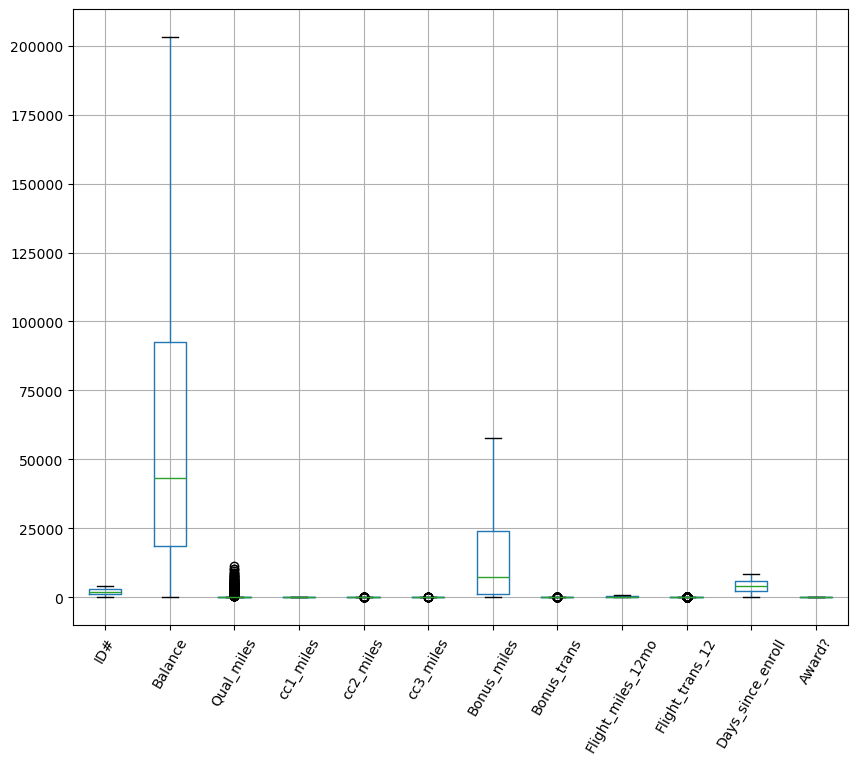

In [66]:
### After Outlier capping
### Check Outliers
plt.figure(figsize=(10,8))
df.boxplot()
plt.xticks(rotation=60)
plt.show()

* Outliers in Balance, Bonus_miles, and Flight_miles_12mo have been successfully reduced.
* Most features now have a more balanced distribution with fewer extreme values.
* A few outliers are still present in Qual_miles, which were intentionally retained.
* Overall, the dataset is better prepared for feature scaling and clustering.

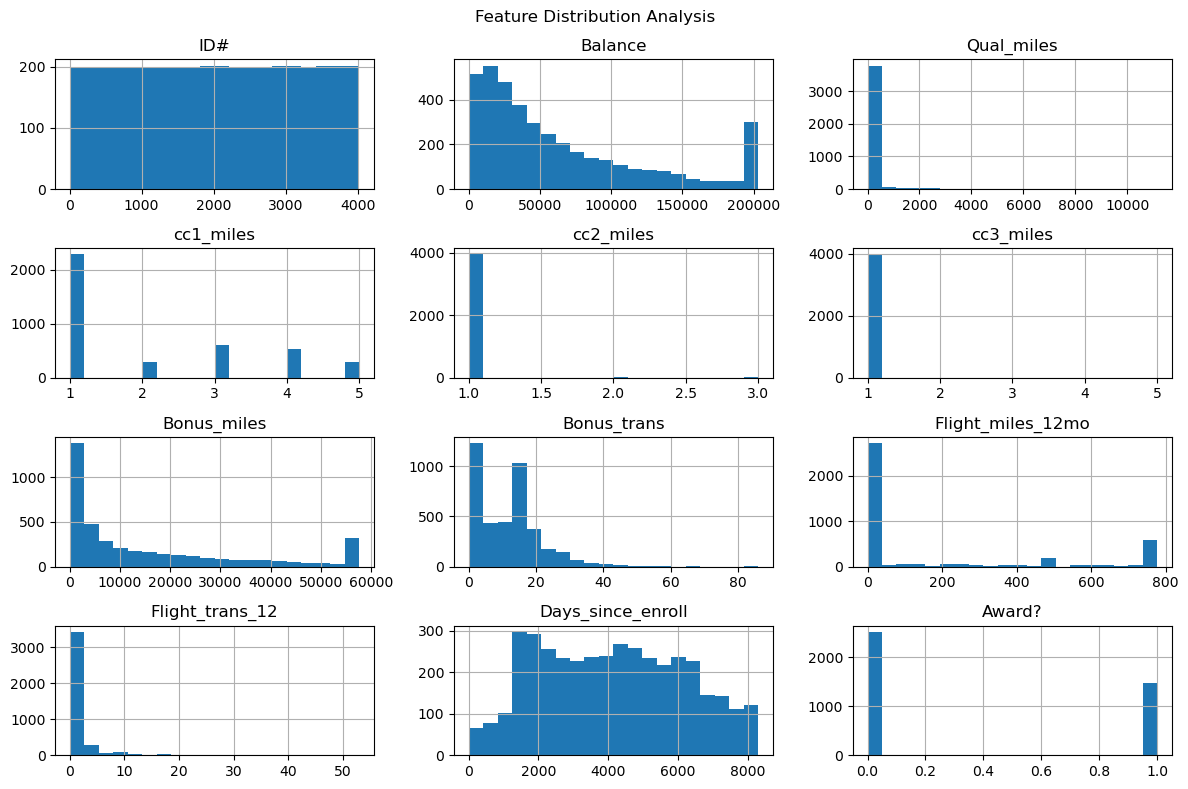

In [69]:
### Histogram for Feature understanding
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distribution Analysis")
plt.tight_layout()
plt.show()

* Most numerical features are right-skewed, with many low values and few high values.
* Balance and Bonus_miles have a wide range of values.
* Flight_miles_12mo and Flight_trans_12 show that most customers travel less frequently.
* cc2_miles, cc3_miles, and Qual_miles have very little variation.
* ID# is only an identifier and should not be used for clustering.

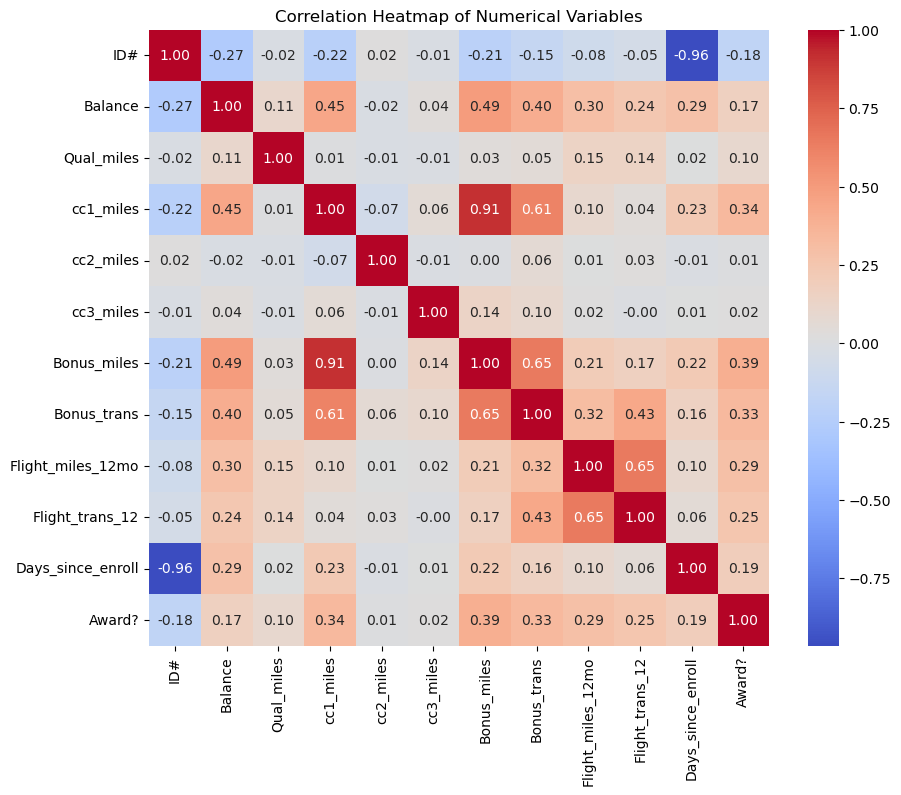

In [68]:
### Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

* Most features have weak to moderate correlations with each other.
* cc1_miles and Bonus_miles show a strong positive correlation (0.91).
* Bonus_miles and Bonus_trans, and Flight_miles_12mo and Flight_trans_12 also have moderate positive correlations.
* ID# has a strong negative correlation with Days_since_enroll and should be removed before clustering since it is only an identifier.

In [70]:
### Remove ID# column
df = df.drop('ID#', axis=1)

In [71]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143.0,0,1,1,1,174.0,1,0.0,0,7000,0
1,19244.0,0,1,1,1,215.0,2,0.0,0,6968,0
2,41354.0,0,1,1,1,4123.0,4,0.0,0,7034,0
3,14776.0,0,1,1,1,500.0,1,0.0,0,6952,0
4,97752.0,0,4,1,1,43300.0,26,777.5,4,6935,1


In [72]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.607258,-0.186299,-0.769578,-0.098242,-0.062767,-0.843091,-1.104065,-0.604313,-0.362168,1.395454,-0.766919
1,-0.758947,-0.186299,-0.769578,-0.098242,-0.062767,-0.840822,-0.999926,-0.604313,-0.362168,1.379957,-0.766919
2,-0.382070,-0.186299,-0.769578,-0.098242,-0.062767,-0.624581,-0.791649,-0.604313,-0.362168,1.411920,-0.766919
3,-0.835106,-0.186299,-0.769578,-0.098242,-0.062767,-0.825052,-1.104065,-0.604313,-0.362168,1.372208,-0.766919
4,0.579265,-0.186299,1.409471,-0.098242,-0.062767,1.543191,1.499394,2.034489,0.692490,1.363975,1.303918


* Feature scaling standardizes all variables to a similar scale.
* It prevents features with larger values from dominating the clustering process.
* Scaling improves the performance of both K-Means and DBSCAN and produces more meaningful clusters.

### Implementing Clustering Algorithms

**K-Mean Clustering**

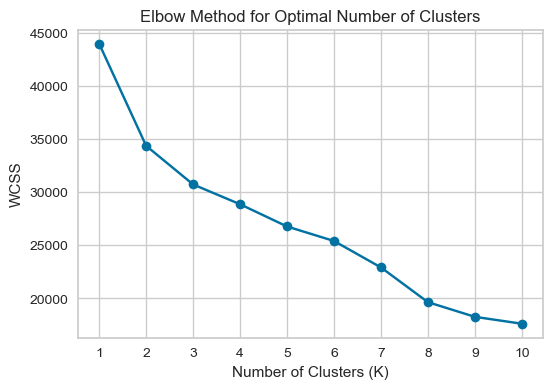

In [88]:
wcss = [] 
for k in range(1, 11): 
    # 1. Initialize the model 
    kmeans = KMeans(n_clusters=k, random_state=50)
    # 2. Fit the data on a separate line
    kmeans.fit(scaled_df)
    # 3. Append the inertia to your list
    wcss.append(kmeans.inertia_)

# The plotting code remains the same
plt.figure(figsize=(6,4)) 
plt.plot(range(1, 11), wcss, marker='o') 
plt.title("Elbow Method for Optimal Number of Clusters") 
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS") 
plt.xticks(range(1, 11)) 
plt.grid(True) 
plt.show()


* The WCSS decreases as the number of clusters increases.
* The optimal number of clusters is selected at the point where the curve starts to flatten, known as the elbow point.
* This optimal K value will be used to build the K-Means clustering model.
* K=3

In [95]:
kmeans = KMeans(n_clusters=3, random_state=50)

df["KMeans_Cluster"] = kmeans.fit_predict(scaled_df)

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,28143.0,0,1,1,1,174.0,1,0.0,0,7000,0,1
1,19244.0,0,1,1,1,215.0,2,0.0,0,6968,0,1
2,41354.0,0,1,1,1,4123.0,4,0.0,0,7034,0,1
3,14776.0,0,1,1,1,500.0,1,0.0,0,6952,0,1
4,97752.0,0,4,1,1,43300.0,26,777.5,4,6935,1,0


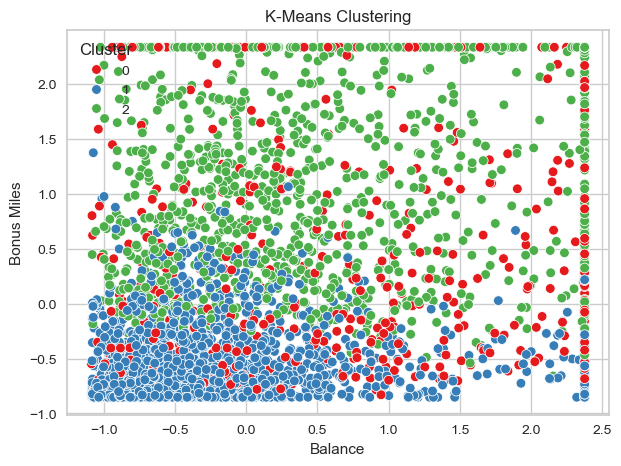

In [97]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=scaled_df["Balance"],
    y=scaled_df["Bonus_miles"],
    hue=df["KMeans_Cluster"],
    palette="Set1"
)

plt.title("K-Means Clustering")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.legend(title="Cluster")
plt.show()

* The data is divided into three distinct clusters.
* The blue cluster contains customers with lower Balance and Bonus Miles.
* The green cluster contains customers with higher Bonus Miles.
* The red cluster lies between the other two clusters and represents customers with moderate values.
* Some overlap is present, indicating that the customer groups are not completely separated.

In [98]:
score = silhouette_score(scaled_df, df["KMeans_Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.28557630237382264


* The Silhouette Score is 0.286.
* This indicates that the clusters are reasonably separated, but there is some overlap between them.
* The clustering has identified meaningful customer groups, although the separation is not very strong.
* Overall, the K-Means model provides an acceptable clustering result for this dataset.

**DBSCAN**

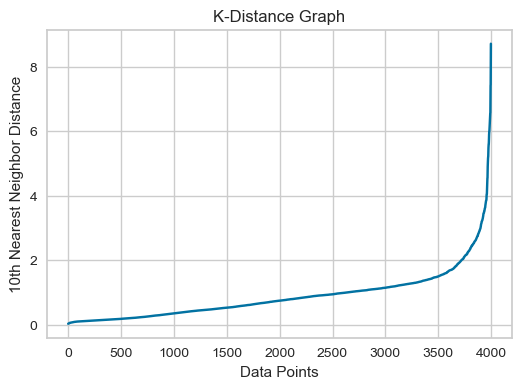

In [117]:
### Find the eps value
n_neigh = NearestNeighbors(n_neighbors=10)

n_neigh.fit(scaled_df)

distances, indices = n_neigh.kneighbors(scaled_df)

distances = np.sort(distances[:, 9])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("10th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

* eps = 1.7
* min_samples = 10

In [118]:
dbscan = DBSCAN(eps=1.7, min_samples=10)

labels = dbscan.fit_predict(scaled_df)

df["DBSCAN_Cluster"] = labels

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,DBSCAN_Cluster
0,28143.0,0,1,1,1,174.0,1,0.0,0,7000,0,1,0
1,19244.0,0,1,1,1,215.0,2,0.0,0,6968,0,1,0
2,41354.0,0,1,1,1,4123.0,4,0.0,0,7034,0,1,0
3,14776.0,0,1,1,1,500.0,1,0.0,0,6952,0,1,0
4,97752.0,0,4,1,1,43300.0,26,777.5,4,6935,1,0,1


In [119]:
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0     2106
 1      971
-1      259
 5      200
 3      166
 6      117
 2       91
 7       30
 4       17
 8       14
 9       14
 10      14
Name: count, dtype: int64

In [120]:
mask = labels != -1

score = silhouette_score(scaled_df[mask], labels[mask])

print("Silhouette Score:", score)

Silhouette Score: 0.19847425406686245


* The Silhouette Score is 0.198.
* This indicates that the clusters have moderate separation, but some overlap still exists.
* DBSCAN successfully identified multiple customer groups and detected 259 noise points (outliers).
* Compared to the earlier parameter settings, the clustering result improved by reducing the number of noise points.
* Overall, the selected eps = 1.7 and min_samples = 10 provide a better clustering result for this dataset.

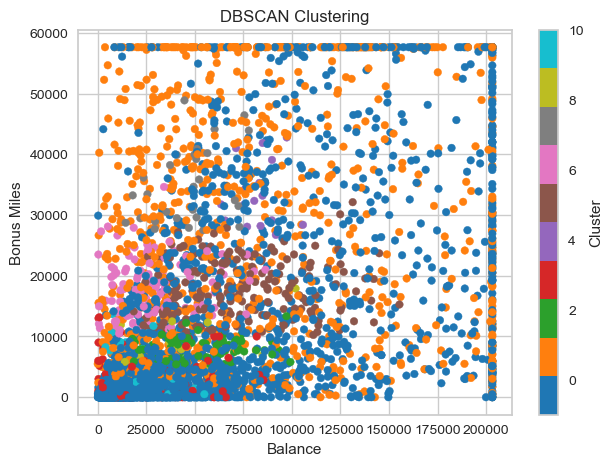

In [122]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Balance"],
    df["Bonus_miles"],
    c=df["DBSCAN_Cluster"],
    cmap="tab10",
    s=30
)

plt.title("DBSCAN Clustering")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")

plt.colorbar(label="Cluster")
plt.show()

* DBSCAN identified multiple clusters with different colors.
* Most customers belong to a few large clusters, while several small clusters are also formed.
* Some data points are classified as noise (cluster -1), indicating outliers.
* There is some overlap between clusters, so the separation is moderate rather than very clear.
* Overall, DBSCAN successfully grouped customers based on data density, but the cluster separation is weaker than K-Means, which is reflected in its lower silhouette score (0.198 vs. 0.286).

### Cluster Analysis and Interpretation

**K-Means Cluster Analysis**

In [123]:
df.groupby("KMeans_Cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,
0,108179.313247,711.011952,2.183267,1.027888,1.009960,22152.283865,20.256972,746.511952,8.247012,4667.111554,0.749004,0.119522
1,37960.650086,61.391081,1.193825,1.018010,1.000429,4103.396226,6.533877,81.404160,0.354202,3664.883791,0.181818,0.743139
2,96292.294635,65.426609,3.739056,1.001717,1.036910,35139.867382,18.017167,126.575966,0.452361,4790.317597,0.584549,1.679828


**K-Means Cluster 0**
* Customers have high balance and high flight miles.
* They also have more flight transactions.
* Most customers have received an award.
* These are frequent flyers.

**K-Means Cluster 1**
* Customers have the lowest balance and lowest bonus miles.
* They have fewer flight and bonus transactions.
* Most customers have not received an award.
* These are low-activity customers.

**K-Means Cluster 2**
* Customers have high bonus miles and higher credit card miles (cc1_miles).
* They have more bonus transactions.
* Many customers have received an award.
* These are loyal customers who actively use airline rewards and credit cards.

**DBSCAN Cluster Analysis**

In [126]:
df.groupby("DBSCAN_Cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,
-1,106670.356178,1788.629344,2.386100,1.169884,1.189189,28024.122587,24.667954,527.401544,8.918919,4540.961390,0.706564,0.498069
0,53638.587607,31.337132,1.543685,1.000000,1.000000,8701.168922,8.095916,116.693970,0.612536,3795.817189,0.000000,1.116334
1,86748.386972,48.468589,2.908342,1.000000,1.000000,28140.276519,15.754892,329.626159,1.901133,4813.597322,1.000000,1.289392
2,47272.956044,0.000000,2.000000,1.000000,1.000000,7861.296703,12.857143,0.549451,0.010989,3597.450549,0.000000,1.000000
3,24174.024096,0.000000,1.000000,1.000000,1.000000,2777.012048,4.373494,5.710843,0.054217,3962.337349,1.000000,1.000000
4,82153.705882,0.000000,4.000000,1.000000,1.000000,33519.764706,15.352941,0.000000,0.000000,6279.176471,0.000000,2.000000
5,72256.745000,0.000000,3.000000,1.000000,1.000000,17721.135000,14.465000,2.750000,0.035000,4064.315000,0.000000,1.560000
6,29185.470085,0.000000,3.000000,1.000000,1.000000,18034.974359,14.905983,5.128205,0.042735,4176.401709,1.000000,1.923077
7,46813.700000,0.000000,4.000000,1.000000,1.000000,34748.800000,14.633333,0.000000,0.000000,3976.200000,1.000000,2.000000


**Cluster 0**

* Customers have a moderate balance and low bonus miles.
* They have fewer flight and bonus transactions.
* Most customers have not received an award.

**Cluster 1**

* Customers have a high balance and high bonus miles.
* They have more bonus and flight transactions.
* All customers in this cluster have received an award.

**Cluster 2**

* Customers have a moderate balance with very few flight activities.
* They have not received many rewards.
* This is a small customer group.

**Cluster 3**

* Customers have the lowest balance and lowest bonus miles.
* They have very few transactions.
* These are low-activity customers.

**Clusters 4 to 10**

* These are small customer groups with unique travel and reward usage patterns.
* Some clusters contain customers with high credit card usage or bonus miles.
* These clusters represent specialized customer segments.

**Noise Cluster (-1)**

* DBSCAN identified these customers as outliers.
* They have unusual travel or reward patterns and do not belong to any main cluster.

### Evaluation and Performance Metrics

**K-Means**
* Silhouette Score: 0.286
* The score indicates moderate cluster separation.
* K-Means formed reasonably well-defined clusters.
    
**DBSCAN**
* Silhouette Score: 0.198
* The score indicates moderate clustering with some overlap.
* DBSCAN also identified 259 noise points (outliers).
    
**Comparison**
* K-Means Silhouette Score: 0.286
* DBSCAN Silhouette Score: 0.198
    
**Conclusion**
* K-Means achieved a higher silhouette score than DBSCAN.
* This indicates that K-Means produced better-separated clusters for this dataset.
* DBSCAN was useful for detecting outliers but showed weaker cluster separation.
* Overall, K-Means performed better for customer segmentation in this dataset.

### Final Summary

* The dataset was preprocessed by checking for missing values, handling outliers, and scaling the features.
* EDA and visualizations were performed to understand the data distribution and patterns.
* The Elbow Method was used to determine the optimal number of clusters for K-Means.
* K-Means clustered the customers into 3 groups with a Silhouette Score of 0.286.
* DBSCAN identified multiple clusters and detected 259 outlier (noise) points, achieving a Silhouette Score of 0.198.
* Comparing both algorithms, K-Means provided better cluster separation, while DBSCAN was effective in identifying outliers.
* Overall, K-Means is the more suitable clustering algorithm for this customer segmentation dataset.